Generating Animation...


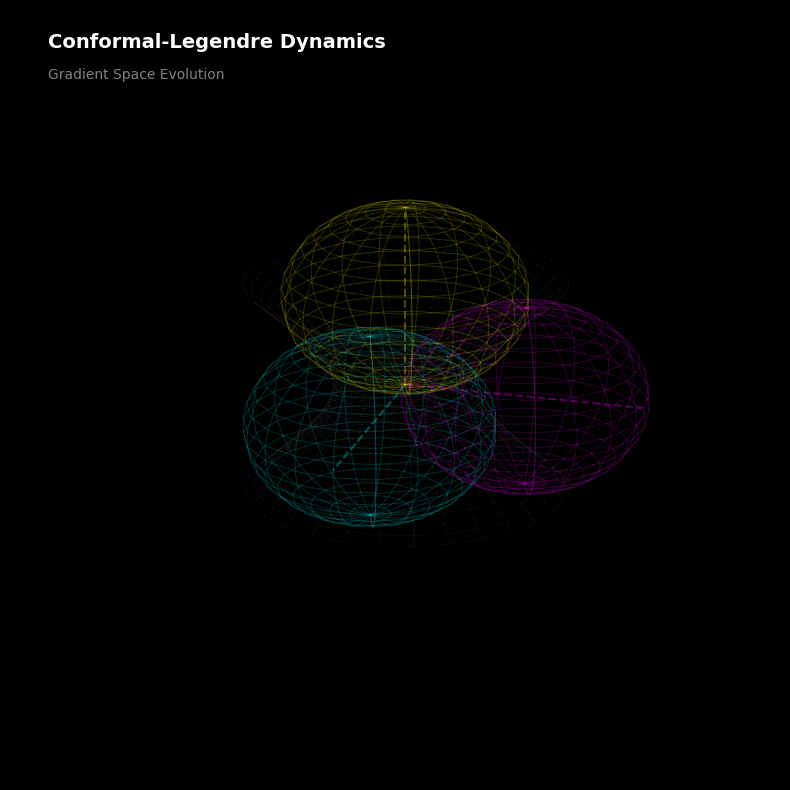

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LightSource

# --- Configuration & Aesthetics ---
plt.style.use('dark_background')
FIG_SIZE = (10, 10)
DPI = 100
FRAMES = 120
FPS = 20

# Neon Color Palette for the 3 Potentials
COLORS = [
    (0.0, 1.0, 1.0), # Cyan (Potential 1)
    (1.0, 0.0, 1.0), # Magenta (Potential 2)
    (1.0, 1.0, 0.0)  # Yellow (Potential 3)
]

def householder_update(y, target_u, lr=0.05):
    """
    Simulates the Conformal-Wasserstein Gradient Flow update.
    
    Math:
    v = y / |y|^2  (Kelvin Transform/Traversal)
    J = (1/|y|^2) * (I - 2*u*u.T)  (Jacobian/Householder)
    dy = J * (target_u - v)
    """
    norm_sq = np.dot(y, y)
    if norm_sq < 1e-6: # Regularization for 0
        norm_sq = 1e-6
        
    # The current traversal vector
    v = y / norm_sq
    
    # The Normalized Gradient Direction
    u_hat = y / np.sqrt(norm_sq)
    
    # Householder Matrix H = I - 2uu^T
    H = np.eye(3) - 2 * np.outer(u_hat, u_hat)
    
    # The Force from the Recognizer (Pulling traversal v towards target u*)
    force = target_u - v
    
    # The Conformal Jacobian adjustment
    dy = (1.0 / norm_sq) * (H @ force)
    
    # Update with geometric dampening (simulating the edge of chaos friction)
    return y + lr * dy

def generate_sphere_mesh(center, radius, resolution=20):
    """Generates coordinates for a 3D sphere."""
    u = np.linspace(0, 2 * np.pi, resolution)
    v = np.linspace(0, np.pi, resolution)
    x = center[0] + radius * np.outer(np.cos(u), np.sin(v))
    y = center[1] + radius * np.outer(np.sin(u), np.sin(v))
    z = center[2] + radius * np.outer(np.ones(np.size(u)), np.cos(v))
    return x, y, z

def generate_hyperboloid_mesh(a=1, b=1, c=1, resolution=30):
    """Generates a 1-sheet hyperboloid representing the manifold curvature."""
    u = np.linspace(-2, 2, resolution)
    v = np.linspace(0, 2 * np.pi, resolution)
    u, v = np.meshgrid(u, v)
    
    x = a * np.sqrt(1 + u**2) * np.cos(v)
    y = b * np.sqrt(1 + u**2) * np.sin(v)
    z = c * u
    return x, y, z

# --- Initialization ---
fig = plt.figure(figsize=FIG_SIZE, dpi=DPI)
ax = fig.add_subplot(111, projection='3d')
ax.set_axis_off() # Clean look

# Initial states for the 3 potentials (slightly perturbed from origin)
# Positions in Gradient Space
particles = [np.random.randn(3) * 0.01 + np.array([0.01, 0.01, 0.01]) for _ in range(3)]
trails = [[p.copy()] for p in particles]

# The "True" Semantic Directions (Target Fibers)
# They will rotate over time to show robustness
base_targets = [
    np.array([1.0, 0.0, 0.0]),
    np.array([0.0, 1.0, 0.0]),
    np.array([0.0, 0.0, 1.0])
]

# --- Animation Loop ---

def update(frame):
    ax.clear()
    ax.set_axis_off()
    
    # Rotation of the camera
    ax.view_init(elev=20, azim=frame * (360/FRAMES))
    
    # Time-varying rotation of the target semantics (The Manifold evolves)
    theta = frame * 0.05
    rotation_matrix = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta), np.cos(theta), 0],
        [0, 0, 1]
    ])
    
    current_targets = [rotation_matrix @ t for t in base_targets]
    
    # --- Draw The Geometric Objects ---
    
    # 1. The Hyperboloid (Background Manifold)
    # Pulsating scale
    scale = 0.5 + 0.1 * np.sin(frame * 0.1)
    hx, hy, hz = generate_hyperboloid_mesh(scale, scale, scale)
    ax.plot_wireframe(hx, hy, hz, color='white', alpha=0.05, linewidth=0.5)

    # 2. The Conformal Spheres (Acceptance Regions) & Particles
    for i in range(3):
        target = current_targets[i] * 1.5 # Scale target distance
        
        # The Acceptance Region in Gradient Space is a Sphere 
        # defined by ||y - target/2|| <= ||target/2||
        sphere_center = target / 2
        sphere_radius = np.linalg.norm(target) / 2
        
        sx, sy, sz = generate_sphere_mesh(sphere_center, sphere_radius)
        
        # Plot Sphere
        ax.plot_wireframe(sx, sy, sz, color=COLORS[i], alpha=0.15, linewidth=0.8)
        
        # Update Particle Physics (The Training Step)
        # The particle 'learns' to move into the sphere
        particles[i] = householder_update(particles[i], target, lr=0.02)
        trails[i].append(particles[i].copy())
        if len(trails[i]) > 20: trails[i].pop(0)
        
        # Draw Particle Trail
        t_arr = np.array(trails[i])
        ax.plot(t_arr[:,0], t_arr[:,1], t_arr[:,2], color=COLORS[i], linewidth=2, alpha=0.8)
        
        # Draw Particle Head
        ax.scatter([particles[i][0]], [particles[i][1]], [particles[i][2]], 
                   color='white', s=50, edgecolors=COLORS[i], linewidth=2)
        
        # Draw vector to center of sphere (The "Target" vector in Primal Space)
        ax.plot([0, target[0]], [0, target[1]], [0, target[2]], 
                color=COLORS[i], linestyle='--', alpha=0.3)

    # Limits
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_zlim(-1.5, 1.5)
    
    # Title
    ax.text2D(0.05, 0.95, "Conformal-Legendre Dynamics", transform=ax.transAxes, 
              color='white', fontsize=14, fontweight='bold')
    ax.text2D(0.05, 0.91, "Gradient Space Evolution", transform=ax.transAxes, 
              color='gray', fontsize=10)

# --- Generate and Save ---
# Note: To save as GIF, requires 'pillow' or 'imagemagick' installed.
print("Generating Animation...")
ani = animation.FuncAnimation(fig, update, frames=FRAMES, interval=1000/FPS)

# Save command (Uncomment to save file locally)
ani.save('conformal_dynamics.gif', writer='pillow', fps=FPS)

plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D

# --- Visual Configuration ---
plt.style.use('dark_background')
FIG_SIZE = (10, 8)
DPI = 100
FRAMES = 120
FPS = 24

# Colors
COLOR_BALL = '#777777'  # Neutral Gray
COLOR_X = '#00FFFF'     # Cyan (Neon)
COLOR_Y = '#FF00FF'     # Magenta (Neon)
COLOR_Z = '#FFFF00'     # Yellow (Neon)
ALPHA_SURFACE = 0.3
ALPHA_WIRE = 0.1

def generate_ellipsoid(rx, ry, rz, res=30):
    """Generates a deformed sphere (Ellipsoid) representing the Conformal Ball."""
    u = np.linspace(0, 2 * np.pi, res)
    v = np.linspace(0, np.pi, res)
    x = rx * np.outer(np.cos(u), np.sin(v))
    y = ry * np.outer(np.sin(u), np.sin(v))
    z = rz * np.outer(np.ones_like(u), np.cos(v))
    return x, y, z

def generate_hyperboloid_sheet(axis, offset, opening=0.5, res=20, limit=2.0):
    """
    Generates a single sheet of a hyperboloid opening along a specific axis.
    Equation: axis^2 - (other^2 + other^2) = offset^2
    """
    # Grid for the transverse coordinates
    u = np.linspace(-limit, limit, res)
    v = np.linspace(-limit, limit, res)
    U, V = np.meshgrid(u, v)
    
    # Calculate the axial coordinate based on hyperboloid equation
    # x^2 - (y^2 + z^2) = k  =>  x = sqrt(k + y^2 + z^2)
    
    # Ensure we are "outside" the vertex
    # We model the acceptance region: Signal > Noise + Offset
    R2 = U**2 + V**2
    # We add a small epsilon to offset to prevent sqrt(negative) during transient overlap
    # though graphically we just shift the vertex.
    
    # The distance from origin to vertex is 'offset'
    # The shape is determined by 'opening'
    
    W = np.sqrt(offset**2 + opening * R2)
    
    if axis == 'x':
        return W, U, V
    elif axis == 'y':
        return U, W, V
    else: # axis == 'z'
        return U, V, W

def update_graph(frame):
    ax.clear()
    ax.set_axis_off()
    
    # --- Time Dynamics (0.0 to 1.0) ---
    # Smooth sigmoid easing for organic movement
    t = frame / FRAMES
    ease = 1 / (1 + np.exp(-10 * (t - 0.5))) # Sigmoid 
    
    # --- 1. The Conformal Ball Evolution ---
    # Starts small (0.2), expands to stabilization (1.0)
    # Evolving Geometry: Starts spherical, becomes slightly anisotropic (metric sharpening)
    base_r = 0.3 + 0.7 * ease
    
    # Slight contraction on non-principal axes to show "Metric Tension"
    # It breathes: Expand, then stabilize
    pulse = 1.0 + 0.05 * np.sin(t * np.pi * 4)
    
    bx, by, bz = generate_ellipsoid(base_r * pulse, base_r * pulse, base_r * pulse)
    ax.plot_surface(bx, by, bz, color=COLOR_BALL, alpha=0.6, 
                    rstride=2, cstride=2, linewidth=0, shade=True)
    
    # --- 2. The Recognizer Hyperboloids Evolution ---
    # Start far away (high offset), move inward to touch the ball
    # Start offset: 2.5
    # End offset: matches base_r (1.0) -> The "Kissing" Point
    
    offset_start = 2.5
    offset_end = 1.0 # Must match the max radius of the ball
    current_offset = offset_start - (offset_start - offset_end) * ease
    
    # Generate and Plot the 3 Hyperboloids
    
    # Axis X (Cyan)
    hx, hy, hz = generate_hyperboloid_sheet('x', current_offset)
    ax.plot_surface(hx, hy, hz, color=COLOR_X, alpha=ALPHA_SURFACE, rstride=2, cstride=2)
    ax.plot_wireframe(hx, hy, hz, color=COLOR_X, alpha=ALPHA_WIRE, rstride=5, cstride=5)
    
    # Axis Y (Magenta)
    hy_x, hy_y, hy_z = generate_hyperboloid_sheet('y', current_offset)
    ax.plot_surface(hy_x, hy_y, hy_z, color=COLOR_Y, alpha=ALPHA_SURFACE, rstride=2, cstride=2)
    ax.plot_wireframe(hy_x, hy_y, hy_z, color=COLOR_Y, alpha=ALPHA_WIRE, rstride=5, cstride=5)

    # Axis Z (Yellow)
    hz_x, hz_y, hz_z = generate_hyperboloid_sheet('z', current_offset)
    ax.plot_surface(hz_x, hz_y, hz_z, color=COLOR_Z, alpha=ALPHA_SURFACE, rstride=2, cstride=2)
    ax.plot_wireframe(hz_x, hz_y, hz_z, color=COLOR_Z, alpha=ALPHA_WIRE, rstride=5, cstride=5)
    
    # --- 3. Visual Polish ---
    
    # Camera Rotation
    ax.view_init(elev=25, azim=frame * (360 / FRAMES))
    
    # Limits
    limit = 2.2
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_zlim(-limit, limit)
    
    # Annotations
    status = "Initializing..." if t < 0.2 else ("Stabilizing..." if t > 0.8 else "Evolving...")
    ax.text2D(0.05, 0.95, f"Conformal Metric Evolution", transform=ax.transAxes, 
              color='white', fontsize=14, fontweight='bold')
    ax.text2D(0.05, 0.90, f"Phase: {status}", transform=ax.transAxes, 
              color='gray', fontsize=10)

# --- Setup Figure ---
fig = plt.figure(figsize=FIG_SIZE, dpi=DPI)
ax = fig.add_subplot(111, projection='3d')

print("Generating 3D Conformal Visualization...")
ani = animation.FuncAnimation(fig, update_graph, frames=FRAMES, interval=1000/FPS)

# Save
ani.save('conformal_equilibrium.gif', writer='pillow', fps=FPS)
plt.close()
print("Done. Saved as 'conformal_equilibrium.gif'")

Generating 3D Conformal Visualization...
Done. Saved as 'conformal_equilibrium.gif'


Rendering Volumetric Gaussian Visualization...
Done. Saved as 'gaussian_conformal_convergence.gif'


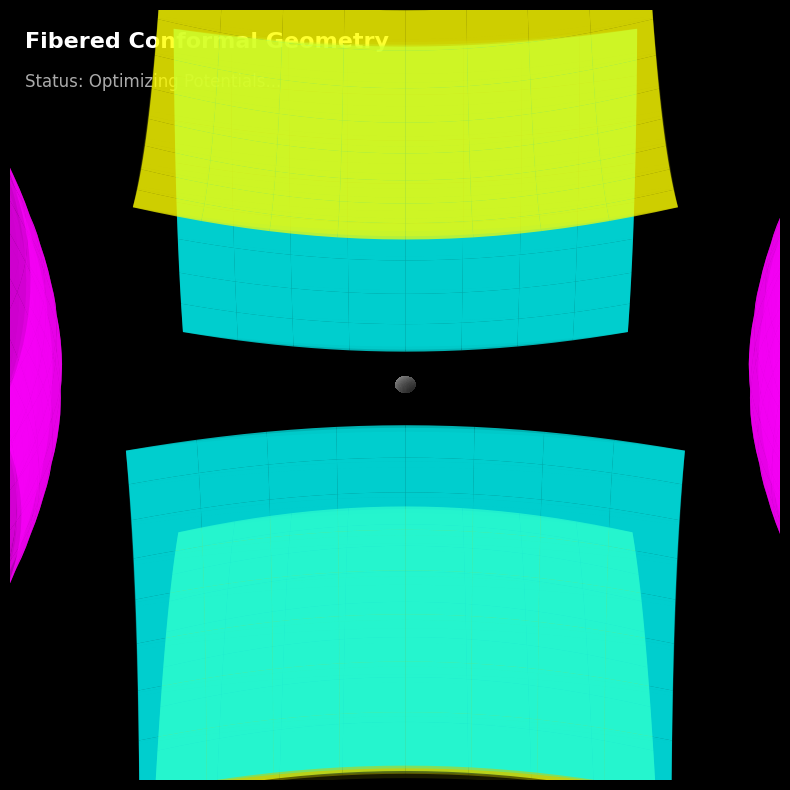

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D

# --- Configuration ---
plt.style.use('dark_background')
FIG_SIZE = (12, 10)
DPI = 100
FRAMES = 120
FPS = 24

# Neon Palette
COLOR_BALL = '#888888'   # Metric Gray
COLOR_X = '#00FFFF'      # Cyan
COLOR_Y = '#FF00FF'      # Magenta
COLOR_Z = '#FFFF00'      # Yellow

def get_ball_mesh(radius, res=40):
    """Generates a high-res smooth sphere mesh."""
    u = np.linspace(0, 2 * np.pi, res)
    v = np.linspace(0, np.pi, res)
    x = radius * np.outer(np.cos(u), np.sin(v))
    y = radius * np.outer(np.sin(u), np.sin(v))
    z = radius * np.outer(np.ones(np.size(u)), np.cos(v))
    return x, y, z

def get_hyperboloid_layers(axis, offset, bend_factor=0.6, res=25, limit=2.5):
    """
    Generates symmetric pairs of hyperboloids.
    Returns a list of (X, Y, Z, alpha) tuples representing 
    nested layers to simulate a volumetric Gaussian blur.
    """
    # Create the grid for the transverse axes
    u = np.linspace(-limit, limit, res)
    v = np.linspace(-limit, limit, res)
    U, V = np.meshgrid(u, v)
    
    # Radial distance squared in the transverse plane
    R2 = U**2 + V**2
    
    layers = []
    
    # We create 3 layers to simulate the Gaussian Core -> Blur
    # 1. Inner Core (Solid, Bright)
    # 2. Mid Glow (Semi-transparent)
    # 3. Outer Haze (Faint)
    
    # Definitions: (layer_offset_modifier, alpha, expansion_modifier)
    layer_defs = [
        (0.0,  0.7,  1.0),  # Core
        (0.1,  0.3,  1.1),  # Glow
        (0.25, 0.1,  1.3)   # Haze
    ]
    
    for mod, alpha, expand in layer_defs:
        # The shape equation: x = sqrt(offset^2 + bend * (y^2+z^2))
        # 'mod' shifts the layer slightly "back" into the acceptance region
        eff_offset = offset + mod 
        
        # 'expand' makes the blur wider
        W = np.sqrt(eff_offset**2 + (bend_factor / expand) * R2)
        
        # Create Positive Sheet
        if axis == 'x':
            layers.append((W, U, V, alpha))  # +X
            layers.append((-W, U, V, alpha)) # -X
        elif axis == 'y':
            layers.append((U, W, V, alpha))  # +Y
            layers.append((U, -W, V, alpha)) # -Y
        else: # z
            layers.append((U, V, W, alpha))  # +Z
            layers.append((U, V, -W, alpha)) # -Z
            
    return layers

def update(frame):
    ax.clear()
    ax.set_axis_off()
    
    # Time variable (0 to 1)
    t = frame / FRAMES
    
    # Easing functions
    # Ball expansion (starts fast, slows down)
    ease_ball = 1 - (1 - t)**3
    # Hyperboloid approach (starts slow, accelerates in, then stabilizes)
    ease_hyp = 1 / (1 + np.exp(-8 * (t - 0.6)))

    # --- 1. Conformal Ball Dynamics ---
    # Radius grows from 0.1 to 1.0
    r_current = 0.1 + 0.9 * ease_ball
    bx, by, bz = get_ball_mesh(r_current)
    
    # Plot Ball (Core)
    ax.plot_surface(bx, by, bz, color=COLOR_BALL, alpha=0.9, 
                    rstride=1, cstride=1, antialiased=False, shade=True)
    
    # --- 2. Hyperboloid Dynamics ---
    # Offset shrinks from 3.0 to 1.0 (The "Kissing Point")
    start_dist = 3.5
    end_dist = 1.0 # Matches max ball radius
    dist_current = start_dist - (start_dist - end_dist) * ease_hyp
    
    # --- 3. Plotting the Gaussian Splotches ---
    
    # Helper to plot a list of layers
    def plot_cloud(layers, color):
        for (X, Y, Z, a) in layers:
            ax.plot_surface(X, Y, Z, color=color, alpha=a, 
                           linewidth=0, shade=False, rstride=3, cstride=3)

    # X-Axis (Cyan)
    layers_x = get_hyperboloid_layers('x', dist_current)
    plot_cloud(layers_x, COLOR_X)
    
    # Y-Axis (Magenta)
    layers_y = get_hyperboloid_layers('y', dist_current)
    plot_cloud(layers_y, COLOR_Y)
    
    # Z-Axis (Yellow)
    layers_z = get_hyperboloid_layers('z', dist_current)
    plot_cloud(layers_z, COLOR_Z)
    
    # --- 4. Scene Setup ---
    limit = 2.5
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_zlim(-limit, limit)
    
    # Camera Rotation
    ax.view_init(elev=30, azim=frame * (360 / FRAMES))
    
    # Labels
    status = "Manifold Stabilization" if t > 0.85 else "Optimizing Potentials..."
    ax.text2D(0.02, 0.95, "Fibered Conformal Geometry", transform=ax.transAxes,
              color='white', fontsize=16, fontweight='bold')
    ax.text2D(0.02, 0.90, f"Status: {status}", transform=ax.transAxes,
              color='#AAAAAA', fontsize=12)

# --- Main Execution ---
fig = plt.figure(figsize=FIG_SIZE, dpi=DPI)
ax = fig.add_subplot(111, projection='3d')

# High quality pane color (make it disappear)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

print("Rendering Volumetric Gaussian Visualization...")
ani = animation.FuncAnimation(fig, update, frames=FRAMES, interval=1000/FPS)

ani.save('gaussian_conformal_convergence.gif', writer='pillow', fps=FPS)
print("Done. Saved as 'gaussian_conformal_convergence.gif'")

/var/folders/nc/zbqbbkkx08z7v1g3mlf8bdn00000gn/T/ipykernel_5066/1689280344.py:64: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k:" (-> color='k'). The keyword argument will take precedence.
  plt.plot(np.cos(theta), np.sin(theta), 'k:', color='white', linewidth=2, alpha=1.0, label="Unit Circle")


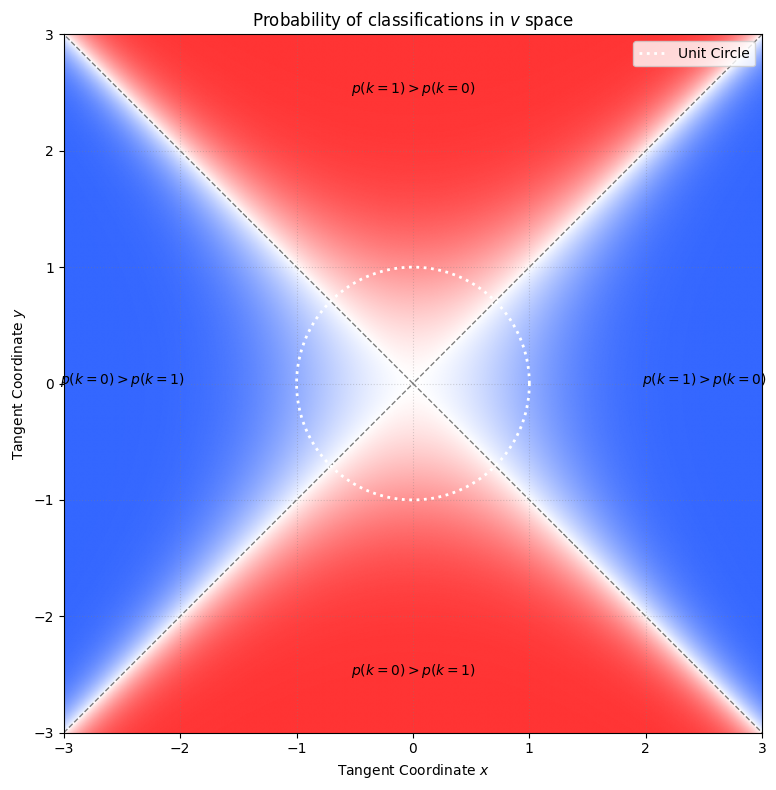

/var/folders/nc/zbqbbkkx08z7v1g3mlf8bdn00000gn/T/ipykernel_5066/1689280344.py:14: RuntimeWarning: overflow encountered in exp
  exp_logits = np.exp(logits)
/var/folders/nc/zbqbbkkx08z7v1g3mlf8bdn00000gn/T/ipykernel_5066/1689280344.py:16: RuntimeWarning: invalid value encountered in divide
  probs = exp_logits / sum_exp


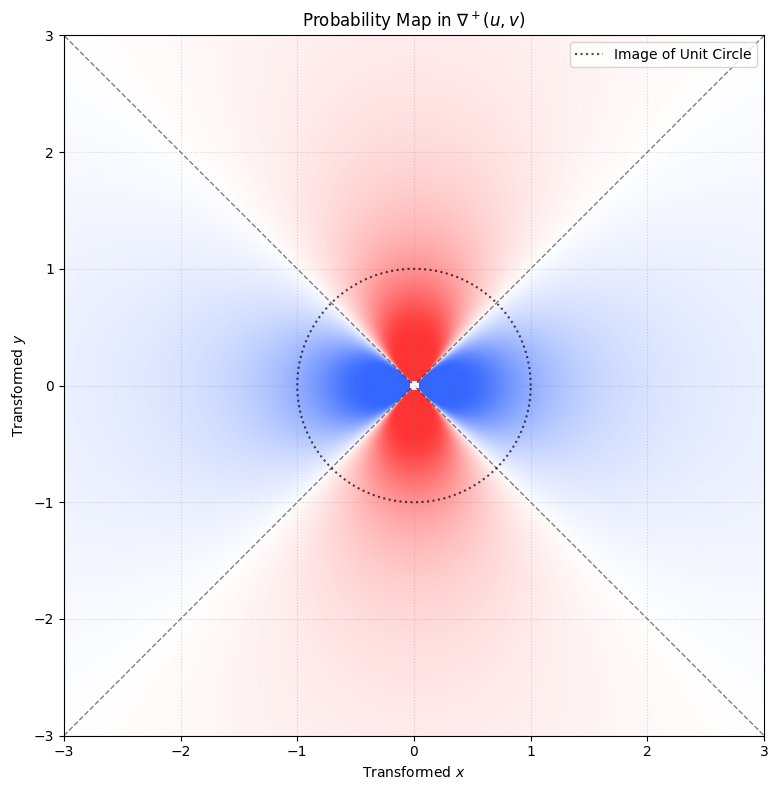

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def compute_logits(X, Y):
    """Compute the logits for each class."""
    # Logit(blue) = |x^2|
    # Logit(red)  = |y^2|
    logit_blue = np.abs(X**2)
    logit_red  = np.abs(Y**2)
    return np.stack([logit_blue, logit_red], axis=-1)

def logits_to_rgba(logits, softmax_axis=-1):
    """Convert logits to an RGBA image and return probabilities for use."""
    exp_logits = np.exp(logits)
    sum_exp = np.sum(exp_logits, axis=softmax_axis, keepdims=True)
    probs = exp_logits / sum_exp

    prob_blue = probs[..., 0]
    prob_red  = probs[..., 1]

    # Build RGBA image
    rgba = np.zeros((*probs.shape[:-1], 4))
    blue_wins = prob_blue > prob_red

    # Blue: [0.2, 0.4, 1.0]
    rgba[blue_wins, 0] = 0.2
    rgba[blue_wins, 1] = 0.4
    rgba[blue_wins, 2] = 1.0

    # Red: [1.0, 0.2, 0.2]
    rgba[~blue_wins, 0] = 1.0
    rgba[~blue_wins, 1] = 0.2
    rgba[~blue_wins, 2] = 0.2

    confidence = np.max(probs, axis=softmax_axis)
    # Alpha: Map confidence in [0.5, 1.0] to [0, 1]
    alpha = (confidence - 0.5) * 2.0
    alpha = np.clip(alpha, 0, 1)
    # Optional: apply gamma curve
    alpha = np.power(alpha, 0.8)
    rgba[..., 3] = alpha

    return rgba, prob_blue, prob_red, confidence

def plot_tangent_space_with_unit_circle():
    # 1. Setup grid
    x = np.linspace(-3, 3, 800)
    y = np.linspace(-3, 3, 800)
    X, Y = np.meshgrid(x, y)

    # 2. Compute logits and RGBA image
    logits = compute_logits(X, Y)
    rgba, prob_blue, prob_red, _ = logits_to_rgba(logits)

    # 3. Plotting
    plt.figure(figsize=(10, 8), dpi=100)
    plt.imshow(rgba, extent=[-3, 3, -3, 3], origin='lower', interpolation='bilinear')

    # Decision boundary: x^2 = y^2
    plt.contour(X, Y, prob_blue - prob_red, levels=[0], colors='black', linestyles='--', linewidths=1, alpha=0.5)

    # Draw unit circle (x^2 + y^2 = 1)
    theta = np.linspace(0, 2*np.pi, 1000)
    plt.plot(np.cos(theta), np.sin(theta), 'k:', color='white', linewidth=2, alpha=1.0, label="Unit Circle (Invariant Set)")

    # Labels and aesthetics
    plt.title("Probability of classifications in $v$ space")

    
    plt.xlabel(r"Tangent Coordinate $x$")
    plt.ylabel(r"Tangent Coordinate $y$")
    plt.grid(True, linestyle=':', alpha=0.3, color='gray')

    plt.text(0, 2.5, "$p(k=1)>p(k=0)$", color='black', ha='center', fontweight='bold')
    plt.text(0, -2.5, "$p(k=0)>p(k=1)$", color='black', ha='center', fontweight='bold')
    plt.text(2.5, 0, "$p(k=1)>p(k=0)$", color='black', ha='center', fontweight='bold')
    plt.text(-2.5, 0, "$p(k=0)>p(k=1)$", color='black', ha='center', fontweight='bold')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

def plot_conformal_map(forward=True):
    """
    Plot the probability map in conformally transformed coordinates.
    Instead of evaluating logits at the original square, we evaluate
    logits at the points of the conformal image of the square,
    and their values are plotted back in the regular square.
    """
    # Regular -3,3 square
    x = np.linspace(-3, 3, 800)
    y = np.linspace(-3, 3, 800)
    Xs, Ys = np.meshgrid(x, y)
    epsilon = 1e-8

    # Map the displayed grid points (Xs, Ys) BACK to conformal domain:
    # Find coordinates (Xc, Yc) in the input space that map (via conformal map) to (Xs, Ys).
    # (u, v) = (x/(x^2+y^2), y/(x^2+y^2))
    # Want to compute logits at points (Xc, Yc) such that 
    #   Xc/(Xc^2+Yc^2) = Xs and Yc/(Xc^2+Yc^2) = Ys
    # So: Xc = Xs*R, Yc = Ys*R, with R = 1/(Xs^2+Ys^2)
    # But that's only true up to scaling (inversion of the conformal map)
    # Actually, for each (u, v), the inverse map is:
    #   (x, y) = (u/(u^2 + v^2), v/(u^2 + v^2))
    denom = Xs**2 + Ys**2 + epsilon
    Xc = Xs / denom
    Yc = Ys / denom
    title = r"$\nabla^+(u, v)$"
    

    # Evaluate logits at the preimage (Xc, Yc)
    logits = compute_logits(Xc, Yc)
    rgba, prob_blue, prob_red, _ = logits_to_rgba(logits)

    plt.figure(figsize=(10, 8), dpi=100)
    plt.imshow(rgba, extent=[-3, 3, -3, 3], origin='lower', interpolation='bilinear')

    # Decision boundary in the displayed coordinates: plot where input logits would be equal
    plt.contour(Xs, Ys, prob_blue - prob_red, levels=[0], colors='black', linestyles='--', linewidths=1, alpha=0.5)

    # Overplot transformed unit circle
    theta = np.linspace(0, 2*np.pi, 1000)
    if forward:
        # parametrize unit circle in source, map through conformal map
        xcirc = np.cos(theta)
        ycirc = np.sin(theta)
        denom_circ = xcirc**2 + ycirc**2 + epsilon
        Xs_circ = xcirc / denom_circ
        Ys_circ = ycirc / denom_circ
        plt.plot(Xs_circ, Ys_circ, 'k:', alpha=0.9, label="Unit Circle (Invariant Set)")
    else:
        xcirc = np.cos(theta)
        ycirc = np.sin(theta)
        denom_x = ycirc**2 + epsilon
        denom_y = xcirc**2 + epsilon
        Xs_circ = xcirc / denom_x
        Ys_circ = ycirc / denom_y
        plt.plot(Xs_circ, Ys_circ, 'k:', alpha=0.9, label="Unit Circle (Invariant Set)")

    plt.title("Probability Map in " + title)
    plt.xlabel(r"Transformed $x$")
    plt.ylabel(r"Transformed $y$")
    plt.grid(True, linestyle=':', alpha=0.3, color='gray')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Original style plot
    plot_tangent_space_with_unit_circle()

    # Conformally map: (x, y) --> (x/(x^2+y^2), y/(x^2+y^2))
    plot_conformal_map(forward=True)


Rendering 2D Conformal Grid animation...
Saved conformal_grid_2d.mp4
Rendering 3D Surface animation...
Saved conformal_manifold_3d.mp4


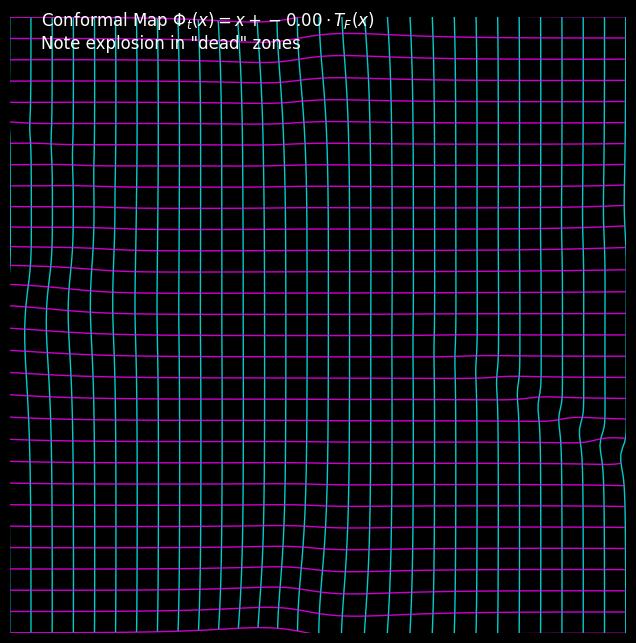

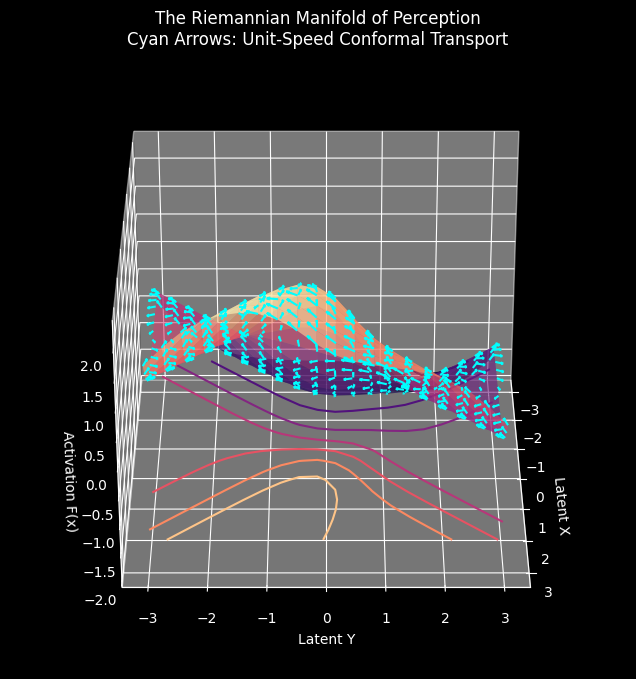

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.collections import LineCollection
from mpl_toolkits.mplot3d import axes3d

# --- Configuration & Aesthetics ---
plt.style.use('dark_background')
GRID_RES = 30
RANGE = 3.0
# Weights for a "Saddle" configuration (XOR-like topology)
# This creates a non-trivial geometry with both active and dead zones.
W = np.array([[1.0, 1.0], 
              [-1.0, 1.0],
              [-0.5, -1.5]])  # 3 Neurons
B = np.array([0.0, 0.0, 1.0])
U = np.array([1.0, -1.0, 0.5]) # Output weights

def tanh(x):
    return np.tanh(x)

def sech2(x):
    return 1.0 - np.tanh(x)**2

def get_F_and_Grad(X, Y):
    """
    Computes the forward pass F(x) and Gradient \nabla F(x)
    for the inputs X, Y (meshgrids).
    """
    # Flatten for vectorized op
    shape = X.shape
    pts = np.vstack([X.ravel(), Y.ravel()]) # (2, N)
    
    # Linear Layer 1: Z = Wx + b
    # W: (m, 2), pts: (2, N), b: (m, 1)
    Z = W @ pts + B[:, None] # (m, N)
    
    # Activation
    H = tanh(Z) # (m, N)
    
    # Linear Layer 2: F = u.H
    F_val = U @ H # (N,)
    
    # Gradient Computation
    # \nabla F = W^T * diag(sigma') * u
    # D = sigma'(Z) = sech^2(Z)
    D = sech2(Z) # (m, N)
    
    # Element-wise scaling of rows of W by D and U
    # grad_F = sum_j (u_j * d_j * w_j)
    # weighted_sensitivities: (m, N)
    weighted_sensitivities = D * U[:, None] 
    
    # Grad: (2, N) = (2, m) @ (m, N)
    Grad = W.T @ weighted_sensitivities 
    
    return F_val.reshape(shape), Grad.reshape(2, *shape)

def get_TF(X, Y, clip_threshold=20.0):
    """
    Computes the Conformal Transform T_F(x) = Grad F / |Grad F|^2.
    Includes clipping to prevent visualization artifacts at singularities.
    """
    F_val, Grad = get_F_and_Grad(X, Y)
    Gx, Gy = Grad[0], Grad[1]
    
    # Squared Norm
    NormSq = Gx**2 + Gy**2
    
    # Avoid division by zero (Singularities at critical points)
    epsilon = 1e-6
    NormSq = np.maximum(NormSq, epsilon)
    
    # Kelvin Transform
    Tx = Gx / NormSq
    Ty = Gy / NormSq
    
    # Soft Clip for visualization (The magnitude goes to infinity in dead zones)
    # We use a tanh compression for the magnitude to keep the plot sane
    mag = np.sqrt(Tx**2 + Ty**2)
    scale_factor = np.tanh(mag / clip_threshold) * clip_threshold / (mag + epsilon)
    
    return Tx * scale_factor, Ty * scale_factor, F_val

# --- Visualization 1: 2D Conformal Grid Warp ---
def generate_grid_lines(xmin, xmax, ymin, ymax, steps):
    lines = []
    colors = []
    
    # Vertical lines
    x = np.linspace(xmin, xmax, steps)
    y = np.linspace(ymin, ymax, steps*4) # higher density for smooth curves
    for xi in x:
        lines.append(np.column_stack([np.full_like(y, xi), y]))
        colors.append('cyan') # Vertical color
        
    # Horizontal lines
    y = np.linspace(ymin, ymax, steps)
    x = np.linspace(xmin, xmax, steps*4)
    for yi in y:
        lines.append(np.column_stack([x, np.full_like(x, yi)]))
        colors.append('magenta') # Horizontal color
        
    return lines, colors

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-RANGE, RANGE)
ax.set_ylim(-RANGE, RANGE)
ax.set_aspect('equal')
ax.axis('off')

# Create initial grid
grid_lines, grid_colors = generate_grid_lines(-RANGE, RANGE, -RANGE, RANGE, GRID_RES)
lc = LineCollection(grid_lines, colors=grid_colors, linewidths=1.0, alpha=0.8)
ax.add_collection(lc)

# Add a title text
title_text = ax.text(0.05, 0.95, '', transform=ax.transAxes, color='white', fontsize=12)

def update_2d(frame):
    # Oscillate t to show flow back and forth
    # t represents the magnitude of the step x -> x + t * TF(x)
    t = 0.15 * np.sin(frame * 0.05) 
    
    new_segments = []
    for segment in grid_lines:
        # Get points of the line segment
        lx, ly = segment[:, 0], segment[:, 1]
        
        # Compute displacement
        Tx, Ty, _ = get_TF(lx, ly)
        
        # Apply Map
        lx_new = lx + t * Tx
        ly_new = ly + t * Ty
        
        new_segments.append(np.column_stack([lx_new, ly_new]))
    
    lc.set_segments(new_segments)
    title_text.set_text(f'Conformal Map $\Phi_t(x) = x + {t:.2f} \cdot T_F(x)$\nNote explosion in "dead" zones')
    return lc, title_text

ani2d = animation.FuncAnimation(fig, update_2d, frames=126, interval=50, blit=True)

# Save 2D Animation
print("Rendering 2D Conformal Grid animation...")
try:
    ani2d.save('conformal_grid_2d.mp4', writer='ffmpeg', fps=30, dpi=100)
    print("Saved conformal_grid_2d.mp4")
except Exception as e:
    print(f"Could not save video (ffmpeg likely missing): {e}")
    plt.show() # Fallback to showing window

# --- Visualization 2: 3D Surface Flow ---
fig3d = plt.figure(figsize=(10, 8))
ax3d = fig3d.add_subplot(111, projection='3d')

# Create mesh
x = np.linspace(-RANGE, RANGE, 20)
y = np.linspace(-RANGE, RANGE, 20)
X, Y = np.meshgrid(x, y)
Tx, Ty, F_val = get_TF(X, Y, clip_threshold=5.0)

# Plot Surface F(x)
surf = ax3d.plot_surface(X, Y, F_val, cmap='magma', alpha=0.6, edgecolor='none')
ax3d.contour(X, Y, F_val, zdir='z', offset=-1.5, cmap='magma')

# Plot Vector Field T_F(x) (Projected onto the surface)
# We calculate the Z component of the vector to make it tangent to the surface?
# Actually, T_F is a vector in Input Space. We verify it moves UP the level sets.
# So we plot (Tx, Ty, 0) rooted at (x, y, F(x)).
# But to visualize the slope, we know <Grad F, T_F> = 1.
# The vertical lift is exactly 1. So the 3D vector is (Tx, Ty, 1).
skip = 1
quiver = ax3d.quiver(X[::skip, ::skip], Y[::skip, ::skip], F_val[::skip, ::skip], 
                     Tx[::skip, ::skip], Ty[::skip, ::skip], np.ones_like(Tx)[::skip, ::skip],
                     length=0.2, color='cyan', normalize=True)

ax3d.set_title("The Riemannian Manifold of Perception\nCyan Arrows: Unit-Speed Conformal Transport")
ax3d.set_xlabel('Latent X')
ax3d.set_ylabel('Latent Y')
ax3d.set_zlabel('Activation F(x)')

def update_3d(frame):
    ax3d.view_init(elev=30, azim=frame)
    return surf,

ani3d = animation.FuncAnimation(fig3d, update_3d, frames=180, interval=50, blit=False)

print("Rendering 3D Surface animation...")
try:
    ani3d.save('conformal_manifold_3d.mp4', writer='ffmpeg', fps=30, dpi=100)
    print("Saved conformal_manifold_3d.mp4")
except:
    plt.show()

Rendering Combined Video (240 frames)...


python(32916) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Saved conformal_evolution.mp4
Rendering Individual GIFs...
Saved saddle.gif
Saved channel.gif
Saved bowl.gif
All renders complete.


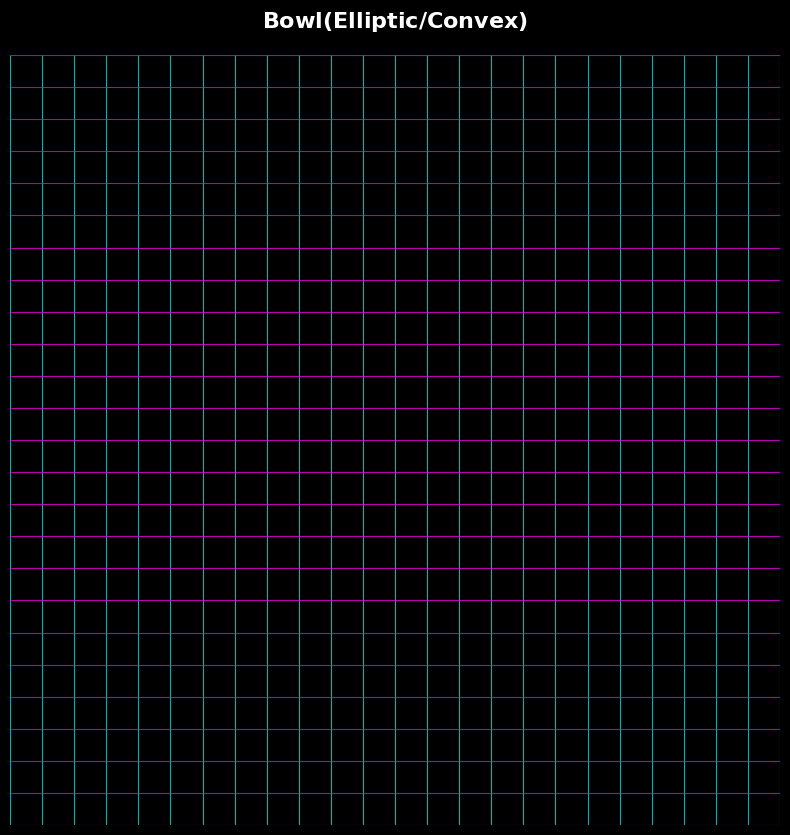

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.collections import LineCollection
import os

# --- Configuration ---
OUTPUT_DIR = 'animations'
GRID_RES = 25
RANGE = 3.5
FRAMES_PER_STAGE = 60  # Frames for each topology
TRANSITION_FRAMES = 30 # Frames to morph between topologies
FPS = 20

# Ensure output directory exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Math Helpers ---
def tanh(x):
    return np.tanh(x)

def sech2(x):
    return 1.0 - np.tanh(x)**2

def get_TF_and_F(X, Y, W, B, U, clip_threshold=15.0):
    """
    Calculates Conformal Transform T_F(x) and Scalar Field F(x)
    for a specific set of weights W, B, U.
    """
    # Flatten
    shape = X.shape
    pts = np.vstack([X.ravel(), Y.ravel()])
    
    # Forward
    Z = W @ pts + B[:, None]
    H = tanh(Z)
    F_val = U @ H
    
    # Gradient
    D = sech2(Z)
    weighted_sensitivities = D * U[:, None]
    Grad = W.T @ weighted_sensitivities
    
    # Conformal Map T_F = Grad / |Grad|^2
    Gx, Gy = Grad[0], Grad[1]
    NormSq = Gx**2 + Gy**2
    epsilon = 1e-6
    NormSq = np.maximum(NormSq, epsilon)
    
    Tx = Gx / NormSq
    Ty = Gy / NormSq
    
    # Soft Clip magnitude for visualization sanity
    mag = np.sqrt(Tx**2 + Ty**2)
    scale_factor = np.tanh(mag / clip_threshold) * clip_threshold / (mag + epsilon)
    
    return (Tx * scale_factor).reshape(shape), (Ty * scale_factor).reshape(shape), F_val.reshape(shape)

# --- Topology Definitions ---
# We define keyframes for the weights to interpolate between.

# 1. The Saddle (Chaotic, XOR-like)
W_saddle = np.array([[1.0, 1.0], [-1.0, 1.0], [-0.5, -1.5]])
B_saddle = np.array([0.0, 0.0, 1.0])
U_saddle = np.array([1.0, -1.0, 0.5])

# 2. The Channel (Two parallel walls, a valley)
W_channel = np.array([[1.0, 0.0], [-1.0, 0.0], [0.0, 0.0]])
B_channel = np.array([-1.0, -1.0, 0.0]) # Offset to create space
U_channel = np.array([1.0, 1.0, 0.0]) # Both sides push up

# 3. The Bowl (Three planes forming a closed triangle)
# Equilateral triangle setup
ang1, ang2, ang3 = 0, 2*np.pi/3, 4*np.pi/3
W_bowl = np.array([
    [np.cos(ang1), np.sin(ang1)],
    [np.cos(ang2), np.sin(ang2)],
    [np.cos(ang3), np.sin(ang3)]
]) * 1.5
B_bowl = np.array([-2.0, -2.0, -2.0]) # Push boundaries out
U_bowl = np.array([1.0, 1.0, 1.0]) # All push up -> Convex basin

STAGES = [
    {"name": "Saddle (Hyperbolic)", "W": W_saddle, "B": B_saddle, "U": U_saddle},
    {"name": "Channel (Parabolic)", "W": W_channel, "B": B_channel, "U": U_channel},
    {"name": "Bowl (Elliptic/Convex)", "W": W_bowl,   "B": B_bowl,   "U": U_bowl}
]

# --- Visualization Setup ---
plt.style.use('dark_background')

def generate_grid_lines(xmin, xmax, ymin, ymax, steps):
    lines = []
    # Vertical
    x = np.linspace(xmin, xmax, steps)
    y = np.linspace(ymin, ymax, steps*5)
    for xi in x: lines.append(np.column_stack([np.full_like(y, xi), y]))
    # Horizontal
    y = np.linspace(ymin, ymax, steps)
    x = np.linspace(xmin, xmax, steps*5)
    for yi in y: lines.append(np.column_stack([x, np.full_like(x, yi)]))
    return lines

# Precompute Grid
grid_lines_base = generate_grid_lines(-RANGE, RANGE, -RANGE, RANGE, GRID_RES)

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlim(-RANGE, RANGE)
ax.set_ylim(-RANGE, RANGE)
ax.set_aspect('equal')
ax.axis('off')

# Graphics Containers
lc = LineCollection([], colors='cyan', linewidths=0.8, alpha=0.7)
ax.add_collection(lc)
# Secondary color for horizontal lines to create the "net" effect
lc_colors = ['cyan'] * (len(grid_lines_base)//2) + ['magenta'] * (len(grid_lines_base)//2)
lc.set_color(lc_colors)

# Title
title_obj = ax.set_title("", fontsize=16, pad=20, color='white')

# --- Animation Logic ---
total_frames = len(STAGES) * FRAMES_PER_STAGE + (len(STAGES)-1) * TRANSITION_FRAMES

def get_interpolated_weights(frame_idx):
    """
    Determines current weights based on frame index.
    Handles morphing between stages.
    """
    # Determine which stage we are in or transitioning to
    cumulative = 0
    for i in range(len(STAGES)):
        # Static Phase
        if frame_idx < cumulative + FRAMES_PER_STAGE:
            return STAGES[i]["W"], STAGES[i]["B"], STAGES[i]["U"], STAGES[i]["name"], i
        
        cumulative += FRAMES_PER_STAGE
        
        # Transition Phase (if not last stage)
        if i < len(STAGES) - 1:
            if frame_idx < cumulative + TRANSITION_FRAMES:
                # Interpolate
                progress = (frame_idx - cumulative) / TRANSITION_FRAMES
                # Smoothstep for nicer morph
                t = progress * progress * (3 - 2 * progress) 
                
                W_curr = (1-t)*STAGES[i]["W"] + t*STAGES[i+1]["W"]
                B_curr = (1-t)*STAGES[i]["B"] + t*STAGES[i+1]["B"]
                U_curr = (1-t)*STAGES[i]["U"] + t*STAGES[i+1]["U"]
                
                # Use only plain text for mode_name during morphing to avoid LaTeX parse errors
                name = f"Morphing: {STAGES[i]['name']} → {STAGES[i+1]['name']}"
                return W_curr, B_curr, U_curr, name, -1 # -1 indicates transition
            
            cumulative += TRANSITION_FRAMES
            
    # Fallback to last
    return STAGES[-1]["W"], STAGES[-1]["B"], STAGES[-1]["U"], STAGES[-1]["name"], len(STAGES)-1

def update(frame):
    W, B, U, mode_name, stage_idx = get_interpolated_weights(frame)
    
    # Breathing effect for the grid warp magnitude
    # It breathes slower to allow inspection
    pulse = 0.15 * np.sin(frame * 0.1)
    
    new_segments = []
    for segment in grid_lines_base:
        lx, ly = segment[:, 0], segment[:, 1]
        Tx, Ty, _ = get_TF_and_F(lx, ly, W, B, U)
        
        # Apply map: x_new = x + pulse * T_F(x)
        lx_new = lx + pulse * Tx
        ly_new = ly + pulse * Ty
        
        new_segments.append(np.column_stack([lx_new, ly_new]))
    
    lc.set_segments(new_segments)
    
    # LaTeX Title: Only use LaTeX for static modes, plain string for transitions
    if stage_idx == -1:
        title_str = mode_name + "\nConformal Map: $x \\mapsto x + \\epsilon T_F(x)$"
    else:
        title_str = r"$\bf{" + mode_name.replace('{', '\\{').replace('}', '\\}') + r"}$" + "\n" + \
                    r"Conformal Map: $x \mapsto x + \epsilon T_F(x)$"
    title_obj.set_text(title_str)
    
    return lc, title_obj

# --- Rendering ---

# 1. The Combined Masterpiece
print(f"Rendering Combined Video ({total_frames} frames)...")
ani = animation.FuncAnimation(fig, update, frames=total_frames, interval=50, blit=False)
try:
    ani.save(os.path.join(OUTPUT_DIR, 'conformal_evolution.mp4'), writer='ffmpeg', fps=FPS, dpi=100)
    print("Saved conformal_evolution.mp4")
except Exception as e:
    print("Video save failed:", e)

# 2. Individual GIFs (by slicing the generator logic essentially)
# To save time, we will just re-run the animation save for specific ranges
# or simpler: just run the loop logic for saving specific files.

print("Rendering Individual GIFs...")

for i, stage in enumerate(STAGES):
    # We create a short loop for just this stage static
    def update_static(f):
        W, B, U = stage["W"], stage["B"], stage["U"]
        pulse = 0.15 * np.sin(f * 0.15)
        
        new_segments = []
        for segment in grid_lines_base:
            lx, ly = segment[:, 0], segment[:, 1]
            Tx, Ty, _ = get_TF_and_F(lx, ly, W, B, U)
            lx_new = lx + pulse * Tx
            ly_new = ly + pulse * Ty
            new_segments.append(np.column_stack([lx_new, ly_new]))
        
        lc.set_segments(new_segments)
        # Ensure braces in names do not break LaTeX title
        safe_title = stage["name"].replace("{", "\\{").replace("}", "\\}")
        title_obj.set_text(r"$\bf{" + safe_title + r"}$")
        return lc, title_obj

    ani_stage = animation.FuncAnimation(fig, update_static, frames=40, interval=50, blit=False)
    safe_name = stage["name"].split(' ')[0].lower()
    try:
        ani_stage.save(os.path.join(OUTPUT_DIR, f'{safe_name}.gif'), writer='pillow', fps=15)
        print(f"Saved {safe_name}.gif")
    except Exception as e:
        print(f"GIF {safe_name} failed:", e)

print("All renders complete.")

Initializing Training Simulation...
  Epoch 1/20 - Convexity Loss: 0.3982
  Epoch 2/20 - Convexity Loss: 0.3245
  Epoch 3/20 - Convexity Loss: 0.3099
  Epoch 4/20 - Convexity Loss: 0.3036
  Epoch 5/20 - Convexity Loss: 0.2997
  Epoch 6/20 - Convexity Loss: 0.2969
  Epoch 7/20 - Convexity Loss: 0.2949
  Epoch 8/20 - Convexity Loss: 0.2934
  Epoch 9/20 - Convexity Loss: 0.2923
  Epoch 10/20 - Convexity Loss: 0.2913
  Epoch 11/20 - Convexity Loss: 0.2906
  Epoch 12/20 - Convexity Loss: 0.2900
  Epoch 13/20 - Convexity Loss: 0.2895
  Epoch 14/20 - Convexity Loss: 0.2890
  Epoch 15/20 - Convexity Loss: 0.2887
  Epoch 16/20 - Convexity Loss: 0.2883
  Epoch 17/20 - Convexity Loss: 0.2881
  Epoch 18/20 - Convexity Loss: 0.2878
  Epoch 19/20 - Convexity Loss: 0.2876
  Epoch 20/20 - Convexity Loss: 0.2874
Rendering Training Animation (1155 frames)...


python(76903) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Saved animations/conformal_training_flow.mp4


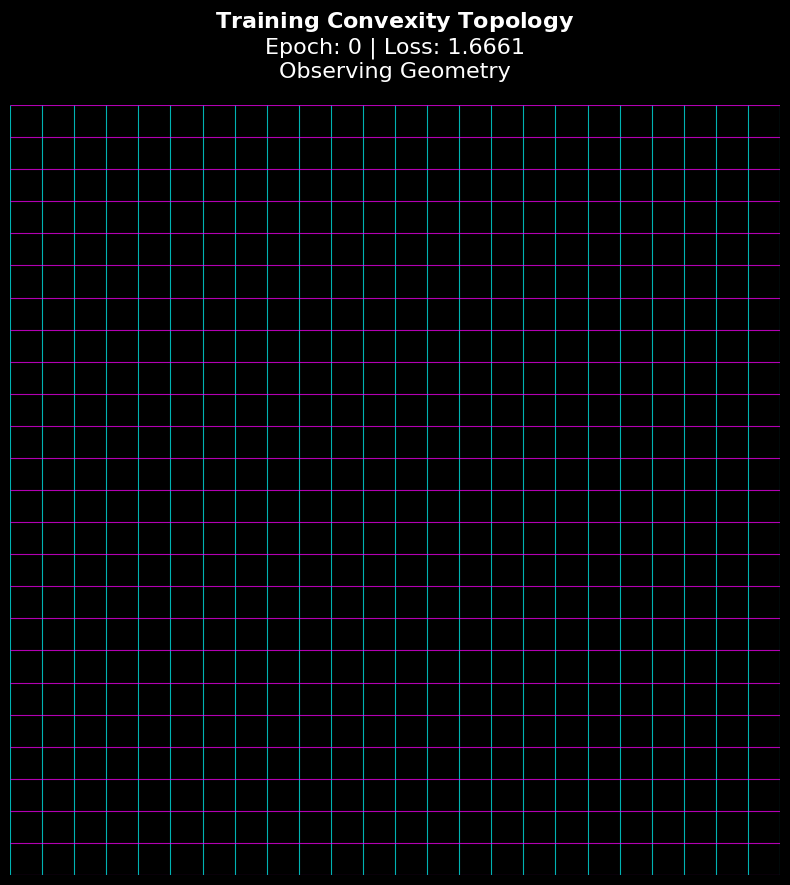

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.collections import LineCollection
import os

# --- Configuration ---
OUTPUT_DIR = 'animations'
GRID_RES = 25
RANGE = 3.0
FPS = 20

# Animation Timing
FRAMES_PER_EPOCH_VIEW = 40  # How long to linger on a specific training stage (breathing grid)
TRANSITION_FRAMES = 15      # How fast to morph weights between training stages
TRAINING_EPOCHS = 20        # Total "checkpoints" to show
TRAINING_STEPS_PER_EPOCH = 150 # Gradient descent steps between checkpoints
LEARNING_RATE = 0.05

os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Math & Neural Network Helpers ---

def tanh(x):
    return np.tanh(x)

def sech2(x):
    return 1.0 - np.tanh(x)**2

def forward(pts, W, B, U):
    """Simple forward pass for training."""
    Z = W @ pts + B[:, None]
    H = tanh(Z)
    return U @ H

def get_TF_and_F(X, Y, W, B, U, clip_threshold=15.0):
    """
    Calculates Conformal Transform T_F(x) and Scalar Field F(x).
    """
    shape = X.shape
    pts = np.vstack([X.ravel(), Y.ravel()])
    
    # Forward
    Z = W @ pts + B[:, None]
    H = tanh(Z)
    F_val = U @ H
    
    # Gradient \nabla F
    D = sech2(Z)
    # grad_F = W^T * (D * u)
    weighted_sensitivities = D * U[:, None]
    Grad = W.T @ weighted_sensitivities
    
    # Conformal Map T_F = Grad / |Grad|^2
    Gx, Gy = Grad[0], Grad[1]
    NormSq = Gx**2 + Gy**2
    epsilon = 1e-6
    NormSq = np.maximum(NormSq, epsilon)
    
    Tx = Gx / NormSq
    Ty = Gy / NormSq
    
    # Soft Clip for visualization
    mag = np.sqrt(Tx**2 + Ty**2)
    scale_factor = np.tanh(mag / clip_threshold) * clip_threshold / (mag + epsilon)
    
    return (Tx * scale_factor).reshape(shape), (Ty * scale_factor).reshape(shape), F_val.reshape(shape)

# --- Training Logic (The "Convexity Loss") ---

# We define convexity loss as the MSE between the network and a Paraboloid (Bowl).
# Minimizing this forces the network topology to become convex.
def loss_function(W, B, U, X_train, Y_train):
    pts = np.vstack([X_train.ravel(), Y_train.ravel()])
    F_pred = forward(pts, W, B, U)
    
    # Target: A simple convex bowl (paraboloid) centered at origin
    # We scale it to match roughly the range of tanh output sums
    F_target = 0.5 * (X_train.ravel()**2 + Y_train.ravel()**2)
    # Normalize target to keep gradients sane
    F_target = F_target / np.max(F_target) * 2.0 - 0.5
    
    loss = np.mean((F_pred - F_target)**2)
    return loss

def compute_gradients_numerical(W, B, U, X_train, Y_train, eps=1e-4):
    """
    Computes gradients via finite differences to avoid complex manual backprop
    derivations for this ad-hoc architecture.
    """
    dW = np.zeros_like(W)
    dB = np.zeros_like(B)
    dU = np.zeros_like(U)
    
    base_loss = loss_function(W, B, U, X_train, Y_train)
    
    # Gradients for W
    for i in range(W.shape[0]):
        for j in range(W.shape[1]):
            W_perturb = W.copy()
            W_perturb[i, j] += eps
            l_perturb = loss_function(W_perturb, B, U, X_train, Y_train)
            dW[i, j] = (l_perturb - base_loss) / eps
            
    # Gradients for B
    for i in range(B.shape[0]):
        B_perturb = B.copy()
        B_perturb[i] += eps
        l_perturb = loss_function(W, B_perturb, U, X_train, Y_train)
        dB[i] = (l_perturb - base_loss) / eps
        
    # Gradients for U
    for i in range(U.shape[0]):
        U_perturb = U.copy()
        U_perturb[i] += eps
        l_perturb = loss_function(W, B, U_perturb, X_train, Y_train)
        dU[i] = (l_perturb - base_loss) / eps
        
    return dW, dB, dU

def generate_training_stages():
    print("Initializing Training Simulation...")
    
    # 1. Initialize Weights (The "Saddle" Configuration from your request)
    W = np.array([[1.0, 1.0], 
                  [-1.0, 1.0],
                  [-0.5, -1.5]])
    B = np.array([0.0, 0.0, 1.0])
    U = np.array([1.0, -1.0, 0.5])
    
    # Training Data (Grid points)
    xt = np.linspace(-RANGE, RANGE, 15)
    yt = np.linspace(-RANGE, RANGE, 15)
    Xt, Yt = np.meshgrid(xt, yt)
    
    stages = []
    
    # Capture initial state
    stages.append({
        "W": W.copy(), "B": B.copy(), "U": U.copy(),
        "epoch": 0, "loss": loss_function(W, B, U, Xt, Yt)
    })
    
    # Training Loop
    current_W, current_B, current_U = W.copy(), B.copy(), U.copy()
    
    for epoch in range(1, TRAINING_EPOCHS + 1):
        # Perform gradient descent steps
        for _ in range(TRAINING_STEPS_PER_EPOCH):
            dW, dB, dU = compute_gradients_numerical(current_W, current_B, current_U, Xt, Yt)
            
            # Update weights (Gradient Descent)
            current_W -= LEARNING_RATE * dW
            current_B -= LEARNING_RATE * dB
            current_U -= LEARNING_RATE * dU
            
        # Checkpoint
        loss = loss_function(current_W, current_B, current_U, Xt, Yt)
        print(f"  Epoch {epoch}/{TRAINING_EPOCHS} - Convexity Loss: {loss:.4f}")
        
        stages.append({
            "W": current_W.copy(), 
            "B": current_B.copy(), 
            "U": current_U.copy(),
            "epoch": epoch, 
            "loss": loss
        })
        
    return stages

# --- Generate the Data ---
STAGES = generate_training_stages()

# --- Visualization Setup ---
plt.style.use('dark_background')

def generate_grid_lines(xmin, xmax, ymin, ymax, steps):
    lines = []
    # Vertical
    x = np.linspace(xmin, xmax, steps)
    y = np.linspace(ymin, ymax, steps*5)
    for xi in x: lines.append(np.column_stack([np.full_like(y, xi), y]))
    # Horizontal
    y = np.linspace(ymin, ymax, steps)
    x = np.linspace(xmin, xmax, steps*5)
    for yi in y: lines.append(np.column_stack([x, np.full_like(x, yi)]))
    return lines

grid_lines_base = generate_grid_lines(-RANGE, RANGE, -RANGE, RANGE, GRID_RES)

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlim(-RANGE, RANGE)
ax.set_ylim(-RANGE, RANGE)
ax.set_aspect('equal')
ax.axis('off')

lc = LineCollection([], colors='cyan', linewidths=0.8, alpha=0.7)
ax.add_collection(lc)
# Coloring scheme: Cyan vertical, Magenta horizontal
lc_colors = ['cyan'] * (len(grid_lines_base)//2) + ['magenta'] * (len(grid_lines_base)//2)
lc.set_color(lc_colors)

title_obj = ax.set_title("", fontsize=16, pad=20, color='white')

# --- Animation Logic ---
# We sequence the animation: 
# For each stage:
#   Show sinusoidal breathing for FRAMES_PER_EPOCH_VIEW
#   Morph to next stage for TRANSITION_FRAMES

def get_animation_state(frame_idx):
    """
    Calculates the exact W, B, U and text for the current frame.
    """
    total_stages = len(STAGES)
    frames_per_block = FRAMES_PER_EPOCH_VIEW + TRANSITION_FRAMES
    
    stage_idx = frame_idx // frames_per_block
    local_frame = frame_idx % frames_per_block
    
    # Clamp to last stage
    if stage_idx >= total_stages:
        stage_idx = total_stages - 1
        local_frame = FRAMES_PER_EPOCH_VIEW # Stay static
    
    current_stage = STAGES[stage_idx]
    next_stage = STAGES[min(stage_idx + 1, total_stages - 1)]
    
    # Are we looking at the static view or transitioning?
    if local_frame < FRAMES_PER_EPOCH_VIEW:
        # Static View (Breathing)
        W, B, U = current_stage["W"], current_stage["B"], current_stage["U"]
        epoch_label = current_stage["epoch"]
        loss_label = current_stage["loss"]
        morph_status = "Observing Geometry"
    else:
        # Transitioning (Morphing weights)
        t_raw = (local_frame - FRAMES_PER_EPOCH_VIEW) / TRANSITION_FRAMES
        t = t_raw * t_raw * (3 - 2 * t_raw) # Smoothstep
        
        W = (1-t)*current_stage["W"] + t*next_stage["W"]
        B = (1-t)*current_stage["B"] + t*next_stage["B"]
        U = (1-t)*current_stage["U"] + t*next_stage["U"]
        
        epoch_label = f"{current_stage['epoch']} \u2192 {next_stage['epoch']}"
        loss_label = (1-t)*current_stage["loss"] + t*next_stage["loss"]
        morph_status = "Backpropagating Convexity Loss..."
        
    return W, B, U, epoch_label, loss_label, morph_status

def update(frame):
    W, B, U, epoch_lbl, loss_lbl, status = get_animation_state(frame)
    
    # Sinusoidal breathing for the grid
    # Pulse represents time 't' in the flow x -> x + t*T_F(x)
    pulse = 0.15 * np.sin(frame * 0.1)
    
    new_segments = []
    for segment in grid_lines_base:
        lx, ly = segment[:, 0], segment[:, 1]
        Tx, Ty, _ = get_TF_and_F(lx, ly, W, B, U)
        
        lx_new = lx + pulse * Tx
        ly_new = ly + pulse * Ty
        
        new_segments.append(np.column_stack([lx_new, ly_new]))
    
    lc.set_segments(new_segments)
    
    # Updated: safer title text (avoid mathtext commands not supported)
    # Only use math mode for bolded main title, the rest as plain text

    title_main = r"$\bf{Training\ Convexity\ Topology}$"
    # Prevent latex parsing of status
    if status == "Observing Geometry":
        status_str = status
    else:
        status_str = status

    # Only bold title, format rest safely as plain non-mathtext
    title_str = (
        title_main + "\n"
        + f"Epoch: {epoch_lbl} | Loss: {loss_lbl:.4f}\n"
        + f"{status_str}"
    )
    title_obj.set_text(title_str)
    return lc, title_obj

total_frames = len(STAGES) * (FRAMES_PER_EPOCH_VIEW + TRANSITION_FRAMES)

print(f"Rendering Training Animation ({total_frames} frames)...")
ani = animation.FuncAnimation(fig, update, frames=total_frames, interval=50, blit=False)

save_path = os.path.join(OUTPUT_DIR, 'conformal_training_flow.mp4')
try:
    ani.save(save_path, writer='ffmpeg', fps=FPS, dpi=100)
    print(f"Saved {save_path}")
except Exception as e:
    print(f"Video save failed: {e}")
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_tangent_space():
    # 1. Setup the 2D Grid (Tangent Space centered at x0)
    # Range from -3 to 3 covers enough variance to see the transition
    x = np.linspace(-3, 3, 800)
    y = np.linspace(-3, 3, 800)
    X, Y = np.meshgrid(x, y)

    # 2. Define the Logits according to the prompt
    # Logit(blue) = |x^2|
    # Logit(red)  = |y^2|
    logit_blue = np.abs(X**2)
    logit_red  = np.abs(Y**2)

    # 3. Compute Softmax Probabilities
    # We stack them to perform the max/sum operations easily
    logits = np.stack([logit_blue, logit_red], axis=-1)
    exp_logits = np.exp(logits)
    sum_exp = np.sum(exp_logits, axis=-1, keepdims=True)
    probs = exp_logits / sum_exp

    # Extract individual class probabilities
    prob_blue = probs[:, :, 0]
    prob_red  = probs[:, :, 1]

    # 4. Construct the Image (RGBA)
    # Initialize an array of zeros: Height x Width x 4 (RGBA)
    img = np.zeros((X.shape[0], X.shape[1], 4))

    # -- Determine Color (Winner take all) --
    # Mask where Blue is the winner
    blue_wins = prob_blue > prob_red

    # Assign Blue Color [0.2, 0.4, 1.0] (Soft Blue)
    img[blue_wins, 0] = 0.2
    img[blue_wins, 1] = 0.4
    img[blue_wins, 2] = 1.0

    # Assign Red Color [1.0, 0.2, 0.2] (Soft Red)
    img[~blue_wins, 0] = 1.0
    img[~blue_wins, 1] = 0.2
    img[~blue_wins, 2] = 0.2

    # -- Determine Transparency (Confidence) --
    # Confidence is the maximum probability at that pixel [0.5, 1.0]
    confidence = np.max(probs, axis=-1)
    
    # Map confidence from [0.5, 1.0] to Alpha [0.0, 1.0]
    # When p=0.5 (boundary), alpha is 0 (transparent). When p=1.0, alpha is 1.
    alpha = (confidence - 0.5) * 2.0
    
    # Apply a slight gamma curve to alpha to make high confidence pop more
    alpha = np.power(alpha, 0.8)
    
    img[:, :, 3] = alpha

    # 5. Plotting
    plt.figure(figsize=(10, 8), dpi=100)
    
    # Show the generated image
    plt.imshow(img, extent=[-3, 3, -3, 3], origin='lower', interpolation='bilinear')
    
    # Overlay Decision Boundary (where x^2 = y^2)
    plt.contour(X, Y, prob_blue - prob_red, levels=[0], colors='black', linestyles='--', linewidths=1, alpha=0.5)

    # Aesthetics
    plt.title("Tangent Space Probability Map\nLogits: Blue=$|x^2|$, Red=$|y^2|$")
    plt.xlabel(r"Tangent Coordinate $x$")
    plt.ylabel(r"Tangent Coordinate $y$")
    plt.grid(True, linestyle=':', alpha=0.3, color='gray')
    
    # Add text annotations for clarity
    plt.text(0, 2.5, "Red Dominant\n($y^2 > x^2$)", color='red', ha='center', fontweight='bold')
    plt.text(0, -2.5, "Red Dominant\n($y^2 > x^2$)", color='red', ha='center', fontweight='bold')
    plt.text(2.5, 0, "Blue\nDominant", color='blue', ha='center', fontweight='bold')
    plt.text(-2.5, 0, "Blue\nDominant", color='blue', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualize_tangent_space()